# (22) conv + vH32:  [512, 8, 8], s=2

**Motivation**: host = ```chewie```, device = ```cuda:1``` <br>

This means:
- ```K = 512```
- ```M = 8```

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Make a model

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH32-wht', model_type, 'ngd|lin')

t_train = 8

cfg_vae['t_train'] = t_train
cfg_vae['kl_beta'] = 4/8 * t_train

cfg_vae['latent_channels'] = 512
cfg_vae['latent_pixels'] = 8
cfg_vae['latent_stride'] = 2

cfg_vae['track_stats'] = True

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.n_iters

180000

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  231.4 K   |
|     ———     |    ———     |
|    layer    |  231.4 K   |
+-------------+------------+

poisson_vH32-wht_t-8_b-4_k-512_m-8_s-2_<ngd|lin>
b200-ep800-lr(0.001)_temp(0.05)_gr(200)_(2025_06_22,09:09)

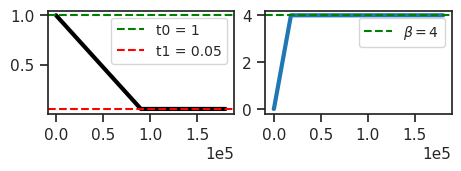

In [5]:
model.print()
tr.print()
tr.show_schedules()

In [6]:
model.layer.n_exp

tensor([10, 10, 10, 10, 10, 10, 10, 10], device='cuda:1', dtype=torch.int32)

In [7]:
print(f"{tr.model.layer}\n{tr.model.layer.dec}")

PoissonLayer(latent_sz=(512, 8, 8), input_sz=(1, 32, 32), temp=1)
ConvDictionary(in_channels=512, out_channels=1, kernel_size=18, stride=2)

In [8]:
tr.model.layer.dec.weight.shape

torch.Size([512, 1, 18, 18])

In [9]:
tr.train('ConvPhi:vH32+M=8+S=2')

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 800, avg loss: 521.176: 100%|█████| 800/800 [25:25:02<00:00, 114.38s/it]


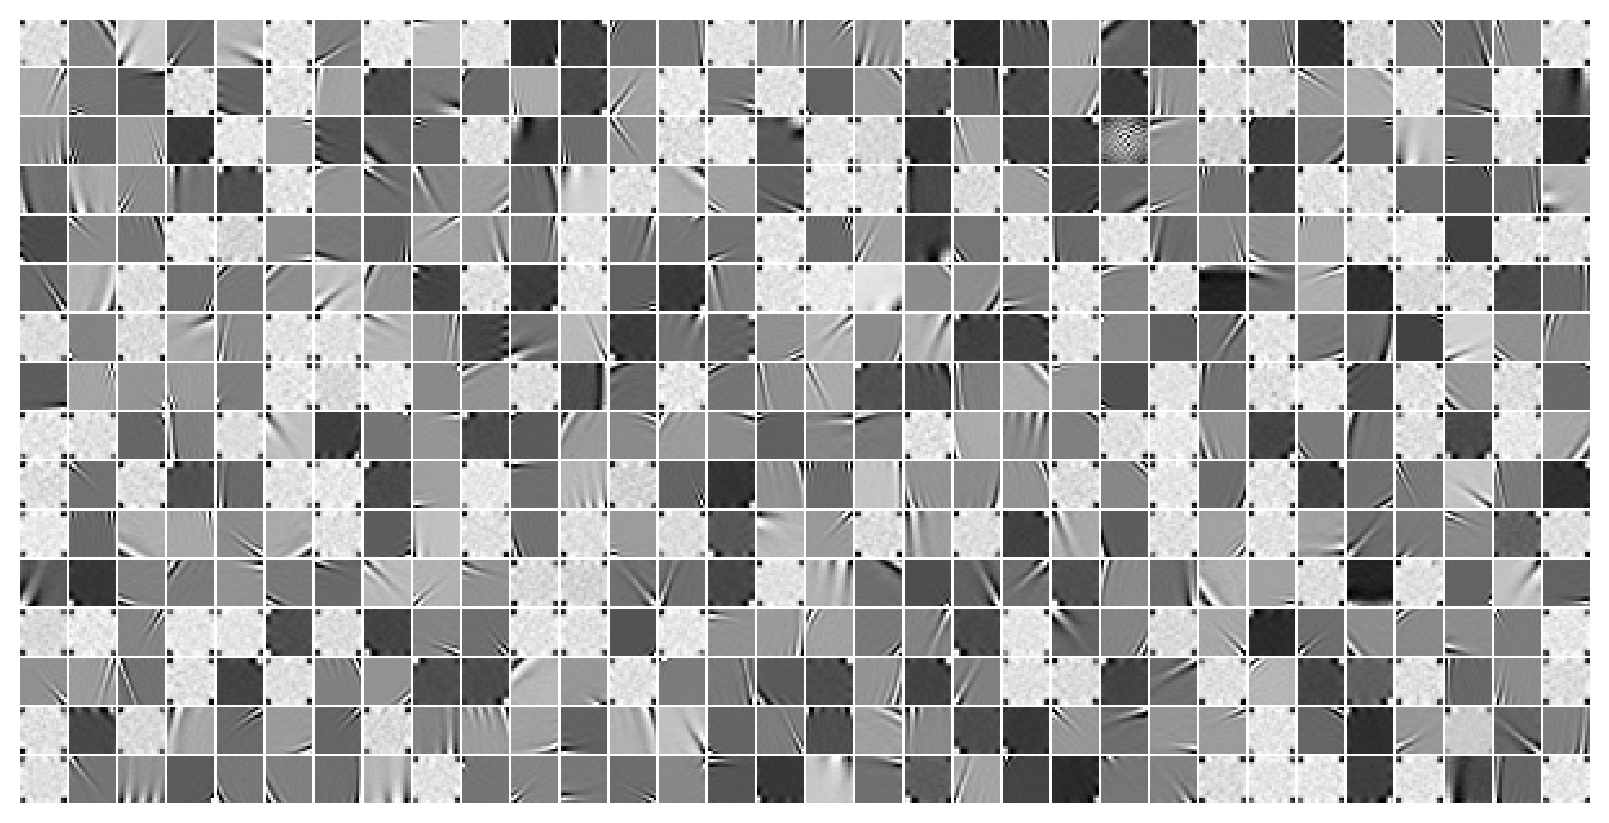

In [10]:
tr.model.show();

100%|███████████████████████████████████| 5/5 [00:52<00:00, 10.55s/it]


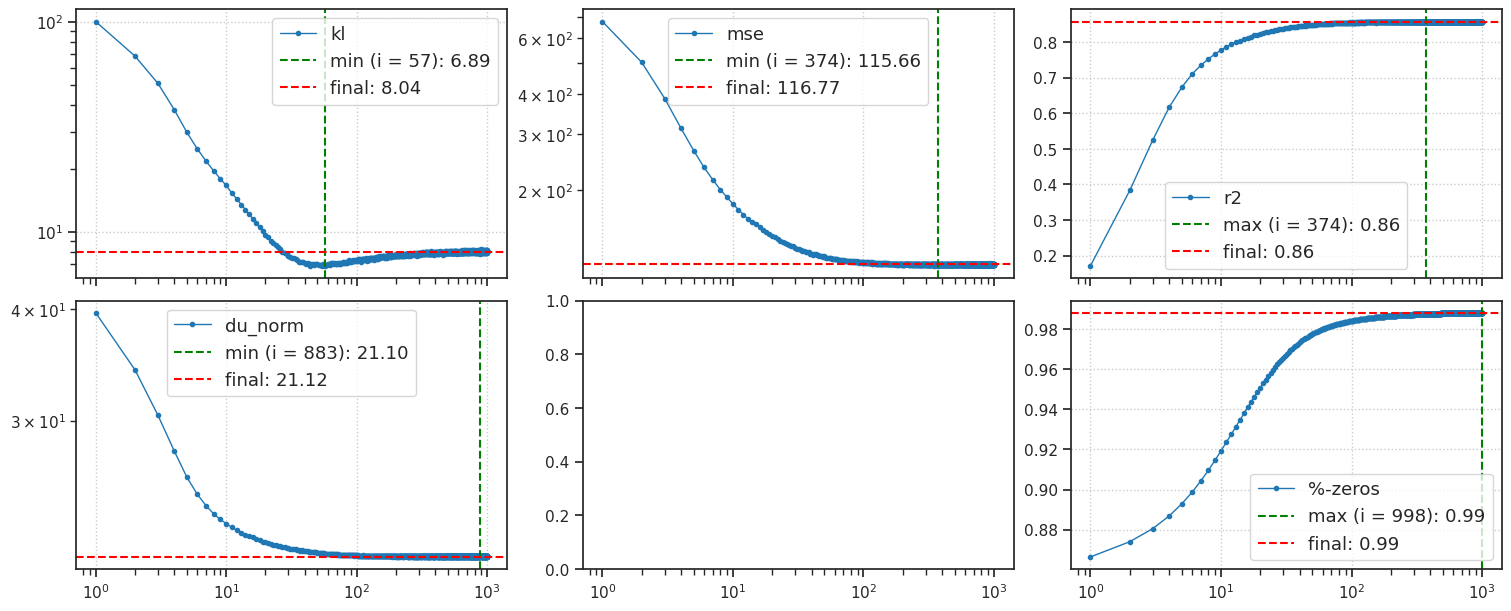

CPU times: user 1min 27s, sys: 46.6 s, total: 2min 13s
Wall time: 2min 13s


In [11]:
%%time

kws = dict(
    t_total=1000,
    n_data_batches=5,
    compute_sprs=False,
)
results = tr.analysis(dl='vld', **kws)
_ = plot_convergence(results, color='C0')

In [4]:
a = 'poisson_vH16-wht_t-8_b-4_k-128_m-8_<ngd|lin>'
b = 'b200-ep300-lr(0.001)_temp(0.05)_gr(200)_ConvPhi:M=8_(2025_06_21,23:44)'
tr, meta = load_model(pjoin(a, b), device)
meta['checkpoint']

300